Development and Evaluation Based Natural Language Processing Model for Sentiment Classification of Twitter Posts on Apple and Google Products

Main Objectives

To develop and evaluate a Natural Language Processing model for 
classifying sentiments expressed in Twitter posts about Apple and Google products.

Specific objectives

To determine the distribution of sentiments toward Apple and Google products on Twitter.

To examine the relationship between targeted products and the sentiments expressed toward them.

To develop and evaluate an NLP model for predicting sentiment from tweet text.

To identify and compare the sentiment distribution of individual Apple and Google products 
on Twitter by determining which products receive the 
highest and lowest levels of positive, negative, and neutral sentiment.

To analyze and compare sentiment across different Apple and Google product categories, 
identifying the categories that generate the highest and 
lowest levels of positive and negative sentiment among Twitter users.

To measure the overall brand sentiment gap between Apple and Google by quantifying positive, 
negative, and neutral mentions and identifying the products that contribute most 
significantly to each brand's sentiment performance.

To determine the volume of positive and negative feedback associated with each Apple and 
Google product and evaluate how these volumes influence overall brand perception on Twitter.

To compare the relative strengths and weaknesses of Apple and Google products based on 
Twitter sentiment patterns, highlighting products that drive favorable and unfavorable user 
opinions.

Research Questions

To determine the distribution of sentiments toward Apple and Google products on Twitter.

To examine the relationship between targeted products and the sentiments expressed toward them.

To develop and evaluate an NLP model for predicting sentiment from tweet text.

Stakeholders

Apple Inc.
Google
Marketing Teams
Product Development Teams
Social Media Analysts
Researchers and Academics
Business Decision Makers
Customers/Consumers


Understanding customer opinions and product perception
Monitoring customer satisfaction and brand reputation
Developing targeted marketing strategies
Improving products based on customer feedback
Tracking brand sentiment trends
Advancing NLP and sentiment analysis studies
Supporting evidence-based decisions
Improving products and services through feedback analysis

Sources of Data

 CrowdFlower Twitter Sentiment Datase

- Loading libraries

In [64]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import string
import html
import unicodedata
import contractions

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import re
from collections import Counter

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import re
import string

# Download NLTK data (run once)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

- load dataset

In [41]:
df = pd.read_csv('tweet_sentiment.csv', encoding='latin-1')

- Data Inspection

In [42]:
# Display first few rows
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [43]:
# Check dataset shape
df.shape

(9093, 3)

9,093 rows (tweets)

3 columns (features)

In [46]:
list(df.columns) # Column names

['tweet_text',
 'emotion_in_tweet_is_directed_at',
 'is_there_an_emotion_directed_at_a_brand_or_product']

In [47]:
df = df.rename(columns={
    'tweet_text': 'Tweet',
    'emotion_in_tweet_is_directed_at': 'Target',
    'is_there_an_emotion_directed_at_a_brand_or_product': 'Sentiment'
})


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet      9092 non-null   object
 1   Target     3291 non-null   object
 2   Sentiment  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


- Summary of dataset

Total rows: 9,093

Columns: 3 (Tweet, Target, Sentiment)

Data type: all object (text/categorical)

In [11]:
# Checking Missing value
df.isnull().sum()

Tweet           1
Target       5802
Sentiment       0
dtype: int64

- Tweet Column

In [12]:
# See tweet distribution
df['Tweet'].value_counts().head()

Tweet
RT @mention Marissa Mayer: Google Will Connect the Digital &amp; Physical Worlds Through Mobile - {link} #sxsw    5
RT @mention Google to Launch Major New Social Network Called Circles, Possibly Today {link} #sxsw                 4
RT @mention Marissa Mayer: Google Will Connect the Digital &amp; Physical Worlds Through Mobile - {link} #SXSW    4
RT @mention Google to Launch Major New Social Network Called Circles, Possibly Today {link} #SXSW                 3
RT @mention ÷¼ GO BEYOND BORDERS! ÷_ {link} ã_ #edchat #musedchat #sxsw #sxswi #classical #newTwitter          2
Name: count, dtype: int64

In [13]:
df['Tweet'].sample(5, random_state=42)

5558    RT @mention best thing abt @mention for #SXSW?...
8350    Gary is starting a new show &quot;Daily Grape&...
2303    The walk by Lady Bird Lake was lovely, but Goo...
927     C34: ItÛªs Not a Retreat! {link} [codes valid...
1963    Holler Gram for iPad on the iTunes App Store: ...
Name: Tweet, dtype: object

In [14]:
# Check Tweet distribution:
df['Tweet'].value_counts()

Tweet
RT @mention Marissa Mayer: Google Will Connect the Digital &amp; Physical Worlds Through Mobile - {link} #sxsw                                 5
RT @mention Google to Launch Major New Social Network Called Circles, Possibly Today {link} #sxsw                                              4
RT @mention Marissa Mayer: Google Will Connect the Digital &amp; Physical Worlds Through Mobile - {link} #SXSW                                 4
RT @mention Google to Launch Major New Social Network Called Circles, Possibly Today {link} #SXSW                                              3
RT @mention ÷¼ GO BEYOND BORDERS! ÷_ {link} ã_ #edchat #musedchat #sxsw #sxswi #classical #newTwitter                                       2
                                                                                                                                              ..
Great interview to @mention on Bloomberg TV about #Ipad2 to kick off #SxSW.#apple {link}                                    

In [15]:
# Count total duplicate tweets (excluding first occurrence)
df.duplicated(subset=['Tweet']).sum()

27

In [16]:
# Percentage of rows that are duplicates
(df.duplicated(subset=['Tweet']).sum() / len(df)) * 100

0.29693170570768723

In [17]:
# See all duplicate tweet rows
df[df.duplicated(subset=['Tweet'], keep=False)].sort_values('Tweet').head(10)

,Tweet,Target,Sentiment
7,"#SXSW is just starting, #CTIA is around the co...",Android,Positive emotion
3962,"#SXSW is just starting, #CTIA is around the co...",Android,Positive emotion
466,"Before It Even Begins, Apple Wins #SXSW {link}",Apple,Positive emotion
468,"Before It Even Begins, Apple Wins #SXSW {link}",Apple,Positive emotion
9,Counting down the days to #sxsw plus strong Ca...,Apple,Positive emotion
2559,Counting down the days to #sxsw plus strong Ca...,Apple,Positive emotion
774,Google to Launch Major New Social Network Call...,NaN,No emotion toward brand or product
776,Google to Launch Major New Social Network Call...,NaN,No emotion toward brand or product
17,I just noticed DST is coming this weekend. How...,iPhone,Negative emotion
8483,I just noticed DST is coming this weekend. How...,iPhone,Negative emotion


In [18]:
# Exact duplicate rows (all columns identical)
df.duplicated().sum()

22

In [49]:
# Find tweets that appear multiple times with different Target/Sentiment
duplicate_tweets = df[df.duplicated(subset=['Tweet'], keep=False)]

inconsistent = duplicate_tweets.groupby('Tweet').filter(
    lambda x: x['Target'].nunique() > 1 or x['Sentiment'].nunique() > 1
)

inconsistent[['Tweet', 'Target', 'Sentiment']].head(10)

,Tweet,Target,Sentiment
3811,Win free ipad 2 from webdoc.com #sxsw RT,NaN,No emotion toward brand or product
3812,Win free iPad 2 from webdoc.com #sxsw RT,NaN,No emotion toward brand or product
3813,Win free ipad 2 from webdoc.com #sxsw RT,iPad,Positive emotion
3814,Win free iPad 2 from webdoc.com #sxsw RT,iPad,Positive emotion
6292,RT @mention Marissa Mayer: Google Will Connect...,Google,Positive emotion
6293,RT @mention Marissa Mayer: Google Will Connect...,Google,Positive emotion
6294,RT @mention Marissa Mayer: Google Will Connect...,NaN,No emotion toward brand or product
6295,RT @mention Marissa Mayer: Google Will Connect...,NaN,No emotion toward brand or product
6296,RT @mention Marissa Mayer: Google Will Connect...,Google,Positive emotion
6297,RT @mention Marissa Mayer: Google Will Connect...,NaN,No emotion toward brand or product


In [20]:
# Remove duplicate tweets, keeping first occurrence
df = df.drop_duplicates(subset=['Tweet'], keep='first')

- Target Column

In [52]:
# Fill missing values first
df['Target'] = df['Target'].fillna('No specific brand')

# Standardize existing categories
df['Target'] = df['Target'].replace({
    'iPad or iPhone App': 'Apple App',
    'Android App': 'Android',
    'Other Google product or service': 'Google',
    'Other Apple product or service': 'Apple'
})


In [53]:
df['Target'] = df['Target'].str.strip()

In [54]:
# See unique Target
df['Target'].unique()

array(['iPhone', 'Apple App', 'iPad', 'Google', 'No specific brand',
       'Android', 'Apple'], dtype=object)

In [55]:
# Include missing values
df['Target'].value_counts(dropna=False)

Target
No specific brand    5802
iPad                  946
Google                723
Apple                 696
Apple App             470
iPhone                297
Android               159
Name: count, dtype: int64

In [56]:
# See what sentiment the 'No specific brand' tweets have
df[df['Target'] == 'No specific brand']['Sentiment'].value_counts()

Sentiment
No emotion toward brand or product    5298
Positive emotion                       306
I can't tell                           147
Negative emotion                        51
Name: count, dtype: int64

- Sentiment Column

In [58]:
# unique Sentiment
df['Sentiment'].unique()

array(['Negative emotion', 'Positive emotion',
       'No emotion toward brand or product', "I can't tell"], dtype=object)

In [27]:
# Check sentiment distribution:
df['Sentiment'].value_counts()

Sentiment
No emotion toward brand or product    5373
Positive emotion                      2968
Negative emotion                       569
I can't tell                           156
Name: count, dtype: int64

In [28]:
# Cross-tabulation to see pattern
pd.crosstab(df['Sentiment'], df['Target'], normalize='columns') * 100

Target,Android,Apple,Apple App,Google,No specific brand,iPad,iPhone
Sentiment,,,,,,,
I can't tell,0.000000,0.288184,0.000000,0.277393,2.540615,0.424178,0.337838
Negative emotion,10.191083,13.976945,13.432836,15.950069,0.881438,13.255567,34.459459
No emotion toward brand or product,1.273885,3.170029,2.132196,3.328710,91.289319,2.545069,3.040541
Positive emotion,88.535032,82.564841,84.434968,80.443828,5.288628,83.775186,62.162162


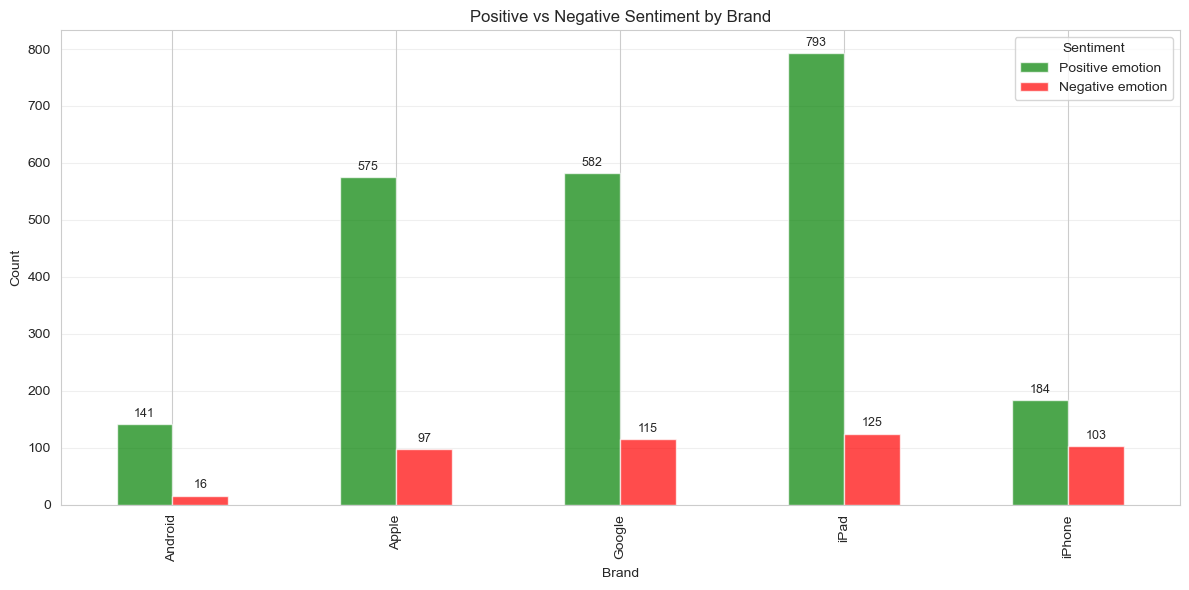

In [ ]:
# filter brands + sentiments
brands = ['Android', 'Apple', 'Google', 'iPad', 'iPhone']
sentiments = ['Positive emotion', 'Negative emotion']

# create crosstab
ct = pd.crosstab(df['Target'], df['Sentiment']).loc[brands, sentiments]

# plot
ax = ct.plot(kind='bar', figsize=(12,6), color=['green','red'], alpha=0.7)

# title + labels
ax.set_title('Positive vs Negative Sentiment by Brand')
ax.set_xlabel('Brand')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)

# 👉 make brand names vertical
plt.xticks(rotation=90)

# 👉 add data labels on bars
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)

plt.tight_layout()
plt.show()

- Overview

- univarient Analysis

C:\Users\user\AppData\Local\Temp\ipykernel_40920\3084140218.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


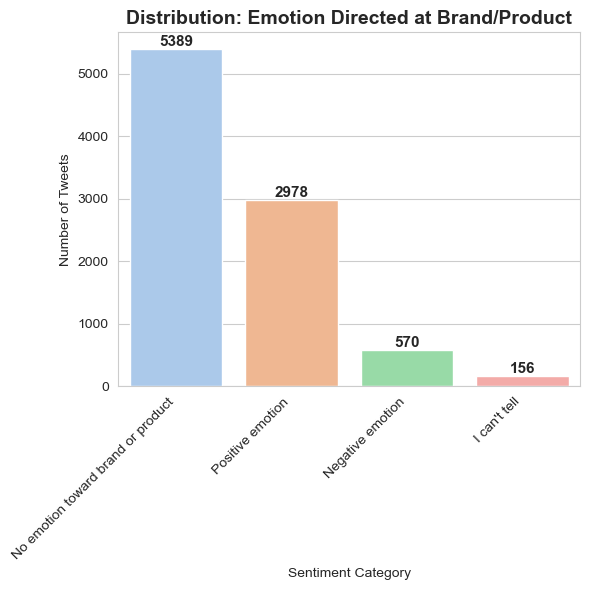

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# style
sns.set_style("whitegrid")

# order once (cleaner)
order = df['Sentiment'].value_counts().index

# plot
plt.figure(figsize=(6, 6))
ax = sns.countplot(
    data=df,
    x='Sentiment',
    order=order,
    palette='pastel'
)

# titles and labels
ax.set_title('Distribution: Emotion Directed at Brand/Product', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment Category')
ax.set_ylabel('Number of Tweets')

# rotate x labels
plt.xticks(rotation=45, ha='right')

# add value labels
for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

- Bivariate Analysis

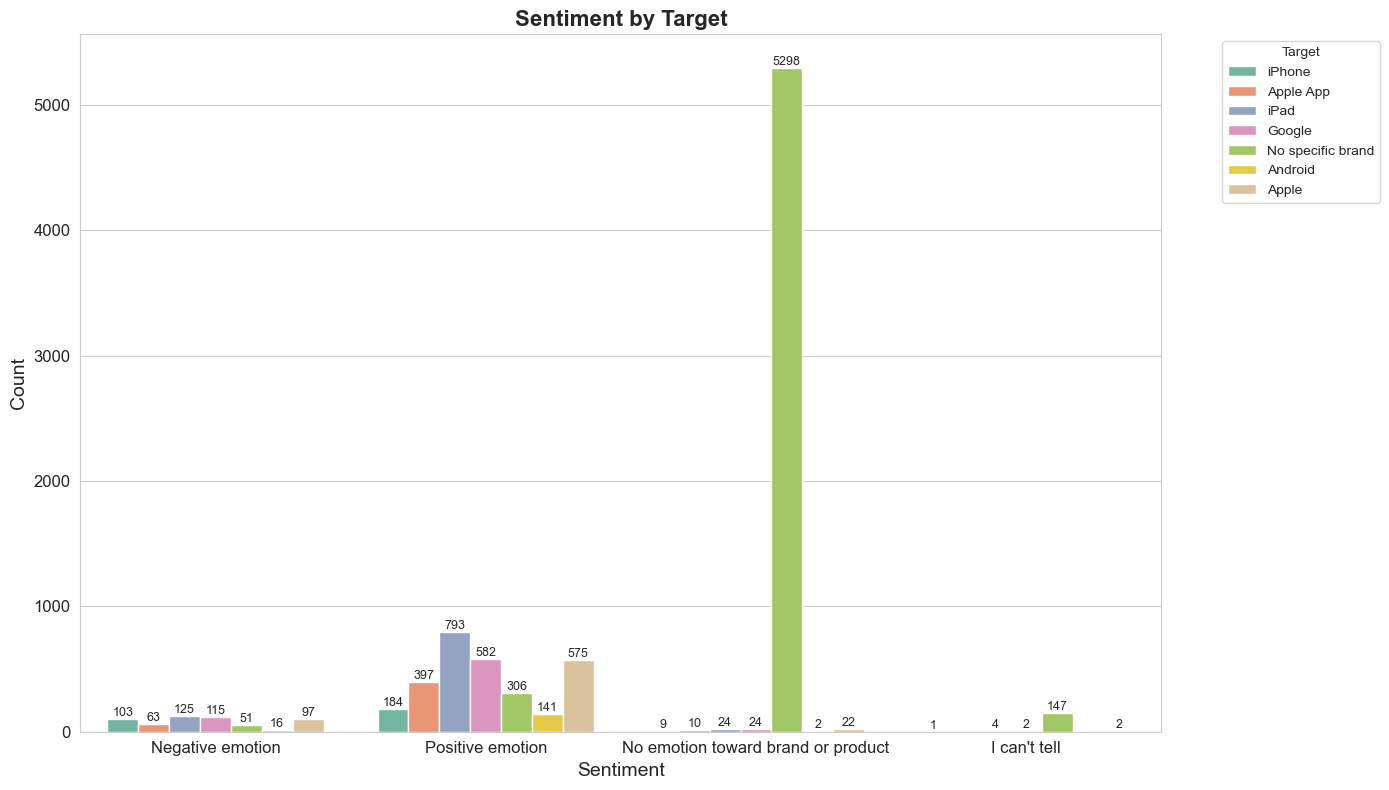

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

ax = sns.countplot(
    data=df,
    x='Sentiment',
    hue='Target',
    palette='Set2'
)

# title + labels
ax.set_title('Sentiment by Target', fontsize=16, fontweight='bold')
ax.set_xlabel('Sentiment', fontsize=14)
ax.set_ylabel('Count', fontsize=14)

# tick formatting
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9)

# legend outside plot
ax.legend(
    title='Target',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

- Multivarient 

In [32]:
pd.crosstab(df['Target'], df['Sentiment'])

Sentiment,I can't tell,Negative emotion,No emotion toward brand or product,Positive emotion
Target,,,,
Android,0,16,2,139
Apple,2,97,22,573
Apple App,0,63,10,396
Google,2,115,24,580
No specific brand,147,51,5282,306
iPad,4,125,24,790
iPhone,1,102,9,184


Data Cleaning 

- Text Preprocessing

In [73]:



# -----------------------------
# 1. CUSTOM STOPWORDS
# -----------------------------
common_english = {
    'the','be','to','of','and','a','in','that','have','i',
    'it','for','not','on','with','he','as','you','do','at',
    'this','but','his','by','from','they','we','say','her','she',
    'or','an','will','my','one','all','would','there','their',
    'what','so','up','out','if','about','who','get','which','go',
    'me','when','make','can','like','time','just','him','know',
    'take','people','into','year','your','good','some','could','them',
    'see','other','than','then','now','look','only','come','its','over',
    'think','also','back','after','use','two','how','our','work',
    'first','well','way','even','new','want','because','any','these',
    'give','day','most','us','is','was','are','been','has','had',
    'were','may','might','must','shall','should','will','would'
}

tech_words = {
    'iphone','ipad','ipod','mac','imac','macbook','apple','ios',
    'android','google','pixel','nexus','samsung','xiaomi','huawei',
    'oneplus','lg','sony','nokia','blackberry','windows','microsoft',
    'surface','xbox','playstation','nintendo','amazon','alexa','echo',
    'facebook','instagram','twitter','tiktok','snapchat','whatsapp',
    'telegram','signal','discord','reddit','linkedin','youtube',
    'netflix','spotify','uber','lyft','airbnb','paypal','venmo',
    'sxsw','sxswi','retweet','tweet','hashtag','viral','post','share','like'
}

stop_words = set(stopwords.words('english')) | common_english


lemmatizer = WordNetLemmatizer()


# -----------------------------
# 2. MEANINGFUL WORD CHECK
# -----------------------------
def is_meaningful_word(word):
    word = word.lower()

    if len(word) < 3:
        return False

    if not any(c.isalpha() for c in word):
        return False

    if not any(c in "aeiou" for c in word):
        return False

    if re.search(r'[^aeiou]{4,}', word):
        return False

    if re.search(r'(.)\1{2,}', word):
        return False

    # Keep known tech words
    if word in tech_words:
        return True

    # Keep normal words
    return word.isalpha()


# -----------------------------
# 3. MAIN CLEANING FUNCTION
# -----------------------------
def clean_text_comprehensive(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # Remove RT
    text = re.sub(r'^RT\s+', '', text, flags=re.IGNORECASE)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Decode HTML entities
    text = html.unescape(text)

    # Normalize unicode
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')

    # Lowercase
    text = text.lower()

    # Remove hashtags symbol only
    text = re.sub(r'#(\w+)', r'\1', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    words = text.split()

    cleaned_words = []
    for w in words:

        # Remove stopwords but keep negation
        if w in stop_words and w not in {"no", "not", "nor", "n't"}:
            continue

        # Meaningful word filter
        if not is_meaningful_word(w):
            continue

        # Lemmatize
        w = lemmatizer.lemmatize(w)

        cleaned_words.append(w)

    return ' '.join(cleaned_words)


# -----------------------------
# 4. APPLY CLEANING
# -----------------------------
df['Cleaned_Tweet'] = df['Tweet'].apply(clean_text_comprehensive)

# Remove empty results
df = df[df['Cleaned_Tweet'].str.len() > 5].copy()


# -----------------------------
# 5. OPTIONAL SECOND PASS FILTER (lightweight)
# -----------------------------
def clean_meaningful_words(text):
    if pd.isna(text):
        return ""

    return ' '.join([w for w in text.split() if is_meaningful_word(w)])


df['Cleaned_Tweet_Final'] = df['Cleaned_Tweet'].apply(clean_meaningful_words)


# -----------------------------
# 6. CHECK RESULTS
# -----------------------------
print("Original:")
print(df['Tweet'].head(3))

print("\nCleaned:")
print(df['Cleaned_Tweet_Final'].head(3))

print("\nDataset size after cleaning:", len(df))

Original:
0    .@wesley83 I have a 3G iPhone. After 3 hrs twe...
1    @jessedee Know about @fludapp ? Awesome iPad/i...
2    @swonderlin Can not wait for #iPad 2 also. The...
Name: Tweet, dtype: object

Cleaned:
0    iphone tweeting riseaustin dead need upgrade p...
1    awesome ipadiphone app youll likely appreciate...
2                                   not wait ipad sale
Name: Cleaned_Tweet_Final, dtype: object

Dataset size after cleaning: 9091


In [34]:
# Save cleaned dataset
df.to_csv('tweets_cleaned_final.csv', index=False)

- Feature Engineering

In [ ]:
df_clean = df[df['Sentiment'] != "I can't tell"].copy()

df_clean['Sentiment'] = df_clean['Sentiment'].replace({
    'Positive emotion': 'Positive',
    'Negative emotion': 'Negative',
    'No emotion toward brand or product': 'Neutral'
})

# Encode labels

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_clean['label'] = le.fit_transform(df_clean['Sentiment'])



In [37]:
# THIS IS RECOMMENDED for your use case
brand_dummies = pd.get_dummies(df['Target'], prefix='Target', drop_first=True, dtype=np.int32)
df = pd.concat([df, brand_dummies], axis=1)
df

,Tweet,Target,Sentiment,Cleaned_Tweet,Sentiment_Encoded,Target_Apple,Target_Apple App,Target_Google,Target_No specific brand,Target_iPad,Target_iPhone
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion,iphone hr tweeting riseaustin dead need upgrad...,0,0,0,0,0,0,1
1,@jessedee Know about @fludapp ? Awesome iPad/i...,Apple App,Positive emotion,know awesome ipadiphone app youll likely appre...,2,0,1,0,0,0,0
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion,not wait ipad also sale sxsw,2,0,0,0,0,1,0
3,@sxsw I hope this year's festival isn't as cra...,Apple App,Negative emotion,hope year festival isnt crashy year iphone app...,0,0,1,0,0,0,0
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion,great stuff fri sxsw marissa mayer google tim ...,2,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9088,Ipad everywhere. #SXSW {link},iPad,Positive emotion,ipad everywhere sxsw link,2,0,0,0,0,1,0
9089,"Wave, buzz... RT @mention We interrupt your re...",No specific brand,No emotion toward brand or product,wave buzz interrupt regularly scheduled sxsw g...,1,0,0,0,1,0,0
9090,"Google's Zeiger, a physician never reported po...",No specific brand,No emotion toward brand or product,google zeiger physician never reported potenti...,1,0,0,0,1,0,0
9091,Some Verizon iPhone customers complained their...,No specific brand,No emotion toward brand or product,verizon iphone customer complained time fell b...,1,0,0,0,1,0,0


- Define X and y

In [74]:
X = df_clean['Cleaned_Tweet_Final']
y = df_clean['label']

- Train and Test

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [76]:
# Convert text → numbers (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

- Baseline Model

BASELINE MODELS (VERY IMPORTANT)

You always start here — even in industry.

Purpose:
Set a performance benchmark
Detect if your features even work
Catch data issues early

In [78]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

baseline_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


- Another Baseline

In [79]:
from sklearn.svm import LinearSVC

svm_baseline = LinearSVC()
svm_baseline.fit(X_train_tfidf, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


- Evaluation of baseline

In [80]:
from sklearn.metrics import classification_report

for model in [baseline_model, svm_baseline]:
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    print(model.__class__.__name__)
    print(classification_report(y_test, preds))
    print("-"*50)

LogisticRegression
              precision    recall  f1-score   support

           0       0.35      0.59      0.44       114
           1       0.77      0.65      0.70      1077
           2       0.56      0.65      0.60       596

    accuracy                           0.64      1787
   macro avg       0.56      0.63      0.58      1787
weighted avg       0.67      0.64      0.65      1787

--------------------------------------------------
LinearSVC
              precision    recall  f1-score   support

           0       0.58      0.33      0.42       114
           1       0.72      0.80      0.76      1077
           2       0.60      0.53      0.56       596

    accuracy                           0.68      1787
   macro avg       0.64      0.56      0.58      1787
weighted avg       0.67      0.68      0.67      1787

--------------------------------------------------


In [81]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [ ]:
HYPERPARAMETER TUNING

In [ ]:
# Train model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_vec, y_train)

- Model Evaluation

In [ ]:
# Evaluate
y_pred = model.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)

- Advanced Models

- Hyperparameter Tuning

- Model Interpretability

- Final Model Selection

- Deployment (Optional)

Save model with joblib

Create prediction function

Build API with FastAPI or Flask
Deploy

- Conclusion

- Recommendation

- Next step